<a href="https://colab.research.google.com/github/hetaf234/GP_Layers/blob/main/Copy_of_Layers_FIXED.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Layers

## Loading And Joining

### Loading From Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import json
import pandas as pd
import os

BASE_PATH = '/content/drive/MyDrive/Graduation_Project/Layers'
LAYER1_PATH = os.path.join(BASE_PATH, 'layer1.json')
LAYER2_PATH = os.path.join(BASE_PATH, 'layer2.json')

print(os.path.exists(LAYER1_PATH), os.path.exists(LAYER2_PATH))

Mounted at /content/drive
True True


In [ ]:
with open(LAYER1_PATH, 'r') as f:
    layer1 = json.load(f)

print(f"Total recipes in layer1: {len(layer1)}")
print(layer1[0])  # inspect one entry to confirm structure

Total recipes in layer1: 1029720
{'ingredients': [{'text': '6 ounces penne'}, {'text': '2 cups Beechers Flagship Cheese Sauce (recipe follows)'}, {'text': '1 ounce Cheddar, grated (1/4 cup)'}, {'text': '1 ounce Gruyere cheese, grated (1/4 cup)'}, {'text': '1/4 to 1/2 teaspoon chipotle chili powder (see Note)'}, {'text': '1/4 cup (1/2 stick) unsalted butter'}, {'text': '1/3 cup all-purpose flour'}, {'text': '3 cups milk'}, {'text': '14 ounces semihard cheese (page 23), grated (about 3 1/2 cups)'}, {'text': '2 ounces semisoft cheese (page 23), grated (1/2 cup)'}, {'text': '1/2 teaspoon kosher salt'}, {'text': '1/4 to 1/2 teaspoon chipotle chili powder'}, {'text': '1/8 teaspoon garlic powder'}, {'text': '(makes about 4 cups)'}], 'url': 'http://www.epicurious.com/recipes/food/views/-world-s-best-mac-and-cheese-387747', 'partition': 'train', 'title': 'Worlds Best Mac and Cheese', 'id': '000018c8a5', 'instructions': [{'text': 'Preheat the oven to 350 F. Butter or oil an 8-inch baking dish.'}

In [ ]:
with open(LAYER2_PATH, 'r') as f:
    layer2 = json.load(f)

print(f"Total entries in layer2: {len(layer2)}")
print(layer2[0])  # inspect one entry

Total entries in layer2: 402760
{'id': '00003a70b1', 'images': [{'id': '3e233001e2.jpg', 'url': 'http://img.sndimg.com/food/image/upload/w_512,h_512,c_fit,fl_progressive,q_95/v1/img/recipes/47/91/49/picaYYmb9.jpg'}, {'id': '7f749987f9.jpg', 'url': 'http://img.sndimg.com/food/image/upload/w_512,h_512,c_fit,fl_progressive,q_95/v1/img/recipes/47/91/49/picpy37SW.jpg'}, {'id': 'aaf6b2dcd3.jpg', 'url': 'http://img.sndimg.com/food/image/upload/w_512,h_512,c_fit,fl_progressive,q_95/v1/img/recipes/47/91/49/picX9CNE2.jpg'}]}


### Cleaning - step 1
here we dropped rows that has empty (Title ,Ingrediets , and has no image)

In [ ]:
# Build id -> list of image ids from layer2
image_lookup = {}
for entry in layer2:
    recipe_id = entry['id']
    images = entry.get('images', [])
    if images:
        image_lookup[recipe_id] = [img['id'] for img in images]

print(f"Recipes with at least one image: {len(image_lookup)}")

# Join with layer1
rows = []
for recipe in layer1:
    rid = recipe['id']
    title = recipe.get('title', '').strip()
    ingredients = [ing['text'] for ing in recipe.get('ingredients', [])]
    partition = recipe.get('partition', '')
    images = image_lookup.get(rid, [])

    if title and ingredients and images:
        rows.append({
            'id': rid,
            'title': title,
            'ingredients': ingredients,
            'num_ingredients': len(ingredients),
            'image_ids': images,
            'partition': partition
        })

df = pd.DataFrame(rows)
print(f"Final clean dataset size: {len(df)}")
df.head()

Recipes with at least one image: 402760
Final clean dataset size: 402760


,id,title,ingredients,num_ingredients,image_ids,partition
0,00003a70b1,Crunchy Onion Potato Bake,"[2 12 cups milk, 1 12 cups water, 14 cup butte...",7,"[3e233001e2.jpg, 7f749987f9.jpg, aaf6b2dcd3.jpg]",test
1,000075604a,Kombu Tea Grilled Chicken Thigh,"[2 Chicken thighs, 2 tsp Kombu tea, 1 White pe...",3,[6bdca6e490.jpg],train
2,00007bfd16,Strawberry Rhubarb Dump Cake,"[6 -8 cups fresh rhubarb, or, 6 -8 cups frozen...",7,"[6409eab844.jpg, f7cb3de295.jpg]",train
3,000095fc1d,Yogurt Parfaits,"[8 ounces, weight Light Fat Free Vanilla Yogur...",3,[a1374cdd98.jpg],train
4,0000b1e2b5,Fennel-Rubbed Pork Tenderloin with Roasted Fen...,"[1 teaspoon fennel seeds, 1 pound pork tenderl...",9,[cb1a684683.jpg],train


In [ ]:

#count partitions
print(df['partition'].value_counts())
print(df['title'].sample(10).tolist())
print(df['num_ingredients'].describe())

partition
train    281598
test      60740
val       60422
Name: count, dtype: int64
['Seafood Noodle-Soup Supper', 'Tempeh with flour batter (TEMPE KEMUL)', 'Cheddar and Veggie Pancakes', 'Potato Balls with Chicken and White Sauce', 'Bruschetta Rustica', 'Mini Taco Bowls', 'Simple Tuna Curry With Rice', 'Turkish Scrambled Eggs (Menemen)', 'Palak Paneer (Spinach Curry)', 'Roasted Brussels Sprouts With Dill']
count    402760.000000
mean          9.205564
std           4.146942
min           1.000000
25%           6.000000
50%           9.000000
75%          12.000000
max          99.000000
Name: num_ingredients, dtype: float64


## Save the cleaned data

In [ ]:
SAVE_PATH = os.path.join(BASE_PATH, '..', 'processed')
os.makedirs(SAVE_PATH, exist_ok=True)

df.to_pickle(os.path.join(SAVE_PATH, 'dataset.pkl'))
print("Saved to:", os.path.join(SAVE_PATH, 'dataset.pkl'))

Saved to: /content/drive/MyDrive/Graduation_Project/Layers/../processed/dataset.pkl


## Check Data Quality

In [ ]:
# Duplicate titles
print("Unique titles:", df['title'].nunique())
print("Total rows:", len(df))
print("Most common titles:")
print(df['title'].value_counts().head(20))

Unique titles: 341958
Total rows: 402760
Most common titles:
title
Banana Bread              91
Guacamole                 88
Chocolate Chip Cookies    70
Chicken Enchiladas        67
Chicken Tortilla Soup     62
Apple Crisp               62
Broccoli Salad            60
French Onion Soup         58
Peanut Butter Cookies     56
Chicken Pot Pie           50
Cucumber Salad            47
Taco Soup                 47
Zucchini Bread            46
Sloppy Joes               46
Meatloaf                  46
Chicken Cacciatore        45
Deviled Eggs              42
Snickerdoodles            41
Carrot Cake               41
Key Lime Pie              40
Name: count, dtype: int64


In [ ]:
# Ingredient count distribution
print(df['num_ingredients'].describe())
print(df[df['num_ingredients'] <= 2].shape[0], "recipes with <=2 ingredients")
print(df[df['num_ingredients'] >= 30].shape[0], "recipes with >=30 ingredients")

count    402760.000000
mean          9.205564
std           4.146942
min           1.000000
25%           6.000000
50%           9.000000
75%          12.000000
max          99.000000
Name: num_ingredients, dtype: float64
5017 recipes with <=2 ingredients
346 recipes with >=30 ingredients


In [ ]:
# Non-ASCII / non-English check (rough heuristic)
non_ascii = df[df['title'].apply(lambda t: not t.isascii())]
print(f"Titles with non-ASCII characters: {len(non_ascii)}")
print(non_ascii['title'].head(10).tolist())

Titles with non-ASCII characters: 0
[]


In [ ]:
title_counts = df['title'].value_counts()

for threshold in [5, 10, 20, 30, 50]:
    n_classes = (title_counts >= threshold).sum()
    n_recipes = title_counts[title_counts >= threshold].sum()
    print(f"Threshold >= {threshold}: {n_classes} classes, covering {n_recipes} recipes")

Threshold >= 5: 3316 classes, covering 29346 recipes
Threshold >= 10: 819 classes, covering 13823 recipes
Threshold >= 20: 186 classes, covering 5555 recipes
Threshold >= 30: 67 classes, covering 2699 recipes
Threshold >= 50: 10 classes, covering 664 recipes


In [ ]:
# Split the dataset into train/val/test using the original partition column
train_df = df[df['partition'] == 'train'].reset_index(drop=True)
val_df = df[df['partition'] == 'val'].reset_index(drop=True)
test_df = df[df['partition'] == 'test'].reset_index(drop=True)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Train: 281598 | Val: 60422 | Test: 60740


In [ ]:
# Load the sentence embedding model
# This converts text titles into numeric vectors that
# capture semantic meaning (not just exact word matches)
from sentence_transformers import SentenceTransformer

model_embed = SentenceTransformer('all-MiniLM-L6-v2')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
import re

def basic_clean(title):
    title = title.lower()
    filler_words = ['quick', 'easy', 'homemade', 'delicious', 'best',
                     'weeknight', 'simple', 'perfect', 'classic', 'traditional']
    for word in filler_words:
        title = title.replace(word, '')
    title = re.sub(r'[^\w\s]', ' ', title)
    return re.sub(r'\s+', ' ', title).strip()

train_df['clean_title'] = train_df['title'].apply(basic_clean)
val_df['clean_title'] = val_df['title'].apply(basic_clean)
test_df['clean_title'] = test_df['title'].apply(basic_clean)

In [ ]:
# Generate embeddings for TRAIN titles only
# We use 'clean_title' (lowercased, punctuation removed)
# instead of the raw 'title' column
train_embeddings = model_embed.encode(
    train_df['clean_title'].tolist(),
    show_progress_bar=True,
    batch_size=128
)

print(f"Embeddings shape: {train_embeddings.shape}")

Batches:   0%|          | 0/2200 [00:00<?, ?it/s]

Embeddings shape: (281598, 384)


K=50: inertia=11256.3
K=100: inertia=10407.5
K=150: inertia=9916.9
K=200: inertia=9557.3
K=300: inertia=9121.9
K=400: inertia=8793.4
K=500: inertia=8525.9
K=700: inertia=8125.4


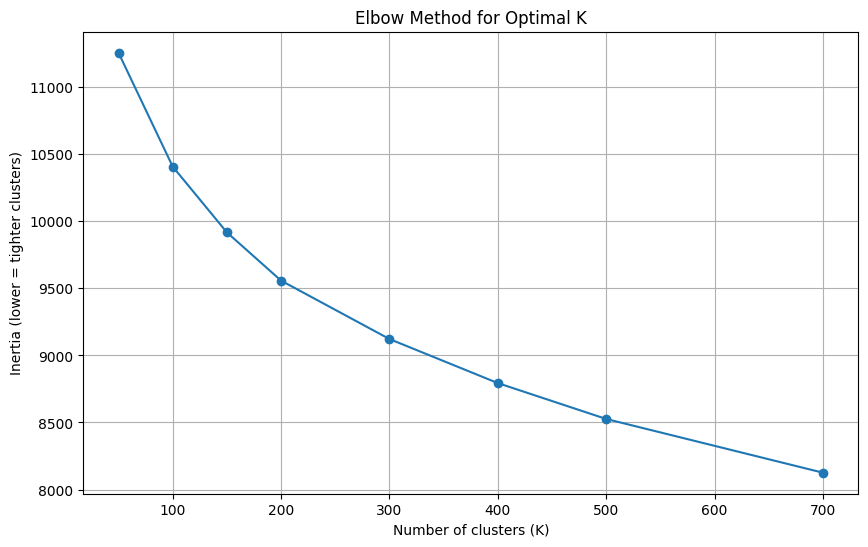

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Use a sample for speed - testing multiple K values on all 281k points is slow
SAMPLE_SIZE = 20000
np.random.seed(42)
sample_indices = np.random.choice(len(train_embeddings), SAMPLE_SIZE, replace=False)
sample_embeddings = train_embeddings[sample_indices]

# Try a range of K values
k_values = [50, 100, 150, 200, 300, 400, 500, 700]
inertias = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=5)
    km.fit(sample_embeddings)
    inertias.append(km.inertia_)
    print(f"K={k}: inertia={km.inertia_:.1f}")

# Plot the elbow curve
plt.figure(figsize=(10, 6))
plt.plot(k_values, inertias, marker='o')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia (lower = tighter clusters)')
plt.title('Elbow Method for Optimal K')
plt.grid(True)
plt.show()

In [ ]:
import os
import pickle
from sklearn.cluster import KMeans

# Re-define PROJECT_PATH in case it was deleted or session restarted
PROJECT_PATH = '/content/drive/MyDrive/Graduation_Project/processed'
os.makedirs(PROJECT_PATH, exist_ok=True)

# Final clustering on the FULL training data (not a sample)
kmeans = KMeans(n_clusters=300, random_state=42, n_init=10)
train_cluster_ids = kmeans.fit_predict(train_embeddings)

# Save the trained clustering model - needed later for val/test
with open(f'{PROJECT_PATH}/kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans, f)

print("Final clustering done on full training data")
print(f"Cluster IDs shape: {train_cluster_ids.shape}")

Final clustering done on full training data
Cluster IDs shape: (281598,)


In [ ]:
import numpy as np
from collections import Counter

cluster_sizes = Counter(train_cluster_ids)
sizes = sorted(cluster_sizes.values(), reverse=True)

print(f"Largest cluster size: {sizes[0]}")
print(f"Smallest cluster size: {sizes[-1]}")
print(f"Average cluster size: {np.mean(sizes):.1f}")
print(f"Number of clusters with less than 50 titles: {sum(1 for s in sizes if s < 50)}")

Largest cluster size: 3363
Smallest cluster size: 167
Average cluster size: 938.7
Number of clusters with less than 50 titles: 0


In [ ]:
from collections import defaultdict
import random

group_examples = defaultdict(list)
for title, cluster_id in zip(train_df['clean_title'], train_cluster_ids):
    group_examples[cluster_id].append(title)

group_sizes_sorted = sorted(group_examples.items(), key=lambda x: -len(x[1]))

def show_group(cluster_id, sample_size=10):
    examples = group_examples[cluster_id]
    sample = random.sample(examples, min(sample_size, len(examples)))
    print(f"\n--- Cluster {cluster_id} ({len(examples)} titles) ---")
    print(sample)

# Start with the 15 largest clusters
for cluster_id, examples in group_sizes_sorted[:15]:
    show_group(cluster_id)


--- Cluster 54 (3363 titles) ---
['shepherd s pie all the taste lower fat', 'shepherd s pie', 'mountain pies', 'cherry pie filling only', 'raspberry cobbler pie', 'my grandma s chocolate pies', '1930 s apple and nut pie', 'mini portuguese kale shepherds pies', 'kangaroo and beer pie with damper pastry', 'grandaddy s sweet potato meringue pie']

--- Cluster 13 (2883 titles) ---
['shrimp stew with grits crust', 'shrimp in coconut milk', 'kickin cajun spicy grilled shrimp', 'tara s shrimp and grits', 'coconut shrimp', 'mexico city shrimp with chipotle mojo', 'sauteed shrimp with gremolata and spiced butter', 'shrimp and fiddlehead', 'creamy garlic shrimp with angel hair pasta', 'dishlycious shrimp']

--- Cluster 97 (2743 titles) ---
['ranch potatoes', 'crispy potato and brie omelet', 'hungarian potatoes', 'saffron potatoes', 'twice baked mashed potatoes', 'southwest mashed potatoes', 'ranch potatoes', 'potato and red pepper frittata', 'lebanese spiced potatoes batata harra', 'fluffy bake

الى هنا ووقفت اللي تحته الكلستر (هتاف)

## start of clustring proccess

In [ ]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')

# Only embed titles that haven't already been matched by keywords, to save compute
unmatched_titles = df[df['dish_class'].isna()]['title'].tolist()
print(f"Embedding {len(unmatched_titles)} unmatched titles...")

embeddings = model.encode(unmatched_titles, batch_size=256, show_progress_bar=True)
print(embeddings.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Embedding 376294 unmatched titles...


Batches:   0%|          | 0/1470 [00:00<?, ?it/s]

(376294, 384)


In [ ]:
from sklearn.cluster import MiniBatchKMeans
import numpy as np

N_CLUSTERS = 500  # starting point — more than we need, we'll prune/merge after inspecting

kmeans = MiniBatchKMeans(n_clusters=N_CLUSTERS, batch_size=1000, random_state=42, n_init=3)
cluster_labels = kmeans.fit_predict(embeddings)

print(f"Assigned {len(cluster_labels)} titles into {N_CLUSTERS} clusters")
print(np.bincount(cluster_labels)[:20])  # cluster sizes for first 20 clusters, just to peek

Assigned 376294 titles into 500 clusters
[ 336  602  287  329 1359  228 1210  768  230  461  497  260  631  609
  187  489 2190 2999 1302  376]


In [ ]:
unmatched_df = df[df['dish_class'].isna()].copy()
unmatched_df['cluster'] = cluster_labels

# Look at 5 random clusters and print sample titles from each
import random
sample_clusters = random.sample(range(N_CLUSTERS), 5)

for c in sample_clusters:
    titles_in_cluster = unmatched_df[unmatched_df['cluster'] == c]['title'].tolist()
    print(f"\n--- Cluster {c} ({len(titles_in_cluster)} titles) ---")
    print(titles_in_cluster[:10])  # first 10 titles in this cluster


--- Cluster 416 (1246 titles) ---
['Classic Lasagna', 'White Vegetable Lasagna', 'Bowtie Lasagna', 'Polenta Lasagna with Creamy Mushroom Sauce', 'Lasagna from the kitchen of Bernie Knight', 'Vegetable Lasagna With White Sauce', 'Cheese Ravioli Lasagna', 'Easy Gooey Lasagna Made with Gyoza Skins', 'Pats Chicken or Beef Lasagna', 'Chef Boyardee Ravioli Lasagna']

--- Cluster 116 (751 titles) ---
['Quick Chocolate Mousse', 'Mango Mousse.. (Egg less)', 'Strawberry Mousse Cake', 'Chocolate Strawberry Mousse Tartlets', 'Raw Vegan Chocolate Cinnamon Mousse', 'Chocolate Mousse Pie', 'Lemon Mousse Napoleons', 'Intense Chocolate Mousse Cake', 'Pumpkin Mousse', 'Strawberry Mousse']

--- Cluster 269 (671 titles) ---
['Catalina Margarita', 'Margarita Kebabs', 'Creamy Nonalcoholic Margaritas', 'Simple Blue Lagoon Margaritas', 'San Diego Style Champagne Margarita', 'Citrus Margarita Cooler - K', 'Winter Pomello Margarita', 'Frozen Strawberry Banana Margaritas', 'Cucumber Margarita', 'Strawberry-Mang

### remove rows with alchole or pork in titles and ingredients

In [ ]:
import re

alcohol_keywords = [
    'margarita', 'daiquiri', 'wine', 'beer', 'whiskey', 'whisky', 'vodka',
    'rum', 'gin', 'tequila', 'bourbon', 'brandy', 'liqueur', 'champagne',
    'sangria', 'mojito', 'cocktail', 'sherry', 'sake', 'mead',
    'kahlua', 'baileys', 'schnapps', 'vermouth', 'ale', 'hard cider'
]

pork_keywords = [
    'pork', 'bacon', 'ham', 'prosciutto', 'sausage', 'chorizo', 'pancetta',
    'salami', 'pepperoni', 'lard', 'pig', 'spam', 'bratwurst', 'carnitas'
]

def build_pattern(keywords):
    # \b = word boundary, so "ham" matches "ham" but not "hamburger" or "hammy"
    # multi-word keywords like "hard cider" still work fine with this pattern
    escaped = [re.escape(kw) for kw in keywords]
    pattern = r'\b(' + '|'.join(escaped) + r')\b'
    return re.compile(pattern, re.IGNORECASE)

alcohol_pattern = build_pattern(alcohol_keywords)
pork_pattern = build_pattern(pork_keywords)

def text_matches(text, pattern):
    return bool(pattern.search(text))

# Title checks
df['title_has_alcohol'] = df['title'].apply(lambda t: text_matches(t, alcohol_pattern))
df['title_has_pork'] = df['title'].apply(lambda t: text_matches(t, pork_pattern))

# Ingredients checks
df['ingredients_have_alcohol'] = df['ingredients'].apply(lambda ing: text_matches(' '.join(ing), alcohol_pattern))
df['ingredients_have_pork'] = df['ingredients'].apply(lambda ing: text_matches(' '.join(ing), pork_pattern))

df['is_alcohol'] = df['title_has_alcohol'] | df['ingredients_have_alcohol']
df['is_pork'] = df['title_has_pork'] | df['ingredients_have_pork']

print(f"Alcohol (combined): {df['is_alcohol'].sum()}")
print(f"Pork (combined): {df['is_pork'].sum()}")
print(f"Total to remove: {(df['is_alcohol'] | df['is_pork']).sum()}")

df_filtered = df[~(df['is_alcohol'] | df['is_pork'])].copy()
print(f"Remaining recipes: {len(df_filtered)} (was {len(df)})")

Alcohol (combined): 54405
Pork (combined): 51748
Total to remove: 98485
Remaining recipes: 304275 (was 402760)


In [ ]:
# Check for suspicious false-positive matches
def find_matches(text, keywords):
    text_lower = text.lower()
    return [kw for kw in keywords if kw in text_lower]

# Sample some flagged pork recipes to check for "ham" false positives
pork_flagged = df[df['is_pork']].copy()
sample = pork_flagged.sample(15, random_state=1)
for _, row in sample.iterrows():
    matches = find_matches(' '.join(row['ingredients']) + ' ' + row['title'], pork_keywords)
    print(f"Title: {row['title']}")
    print(f"  Matched on: {matches}")
    print()

Title: California Turkey Burgers
  Matched on: ['bacon', 'ham']

Title: Bacon Jalapeno poppers
  Matched on: ['bacon']

Title: Quick Pizza Melts
  Matched on: ['pepperoni']

Title: Chef John's Pork and Beans and Greens
  Matched on: ['pork']

Title: Sausage and Pepper Omelet (Low Carb)
  Matched on: ['sausage']

Title: Super Spud Potato Bake
  Matched on: ['bacon']

Title: 4 cheese Mac and cheese
  Matched on: ['bacon']

Title: Basic Italian White Cream Sauce (Like an Alfredo or Bechamel)
  Matched on: ['ham', 'prosciutto']

Title: Italian Sausage Chicken Breasts
  Matched on: ['sausage']

Title: Jalapeno-Bacon Grilled Cheese
  Matched on: ['bacon']

Title: Bacon-Cheddar Mashed Potatoes
  Matched on: ['bacon']

Title: Jills Cheating Potatoes
  Matched on: ['bacon']

Title: Brown Rice Jambalaya
  Matched on: ['sausage', 'chorizo']

Title: Allana's Zesty Red Clam Chowder
  Matched on: ['bacon']

Title: Pan-Seared Trout with Serrano Ham and Chile-Garlic Oil
  Matched on: ['ham']



In [ ]:
# Real test: does the ACTUAL filter still wrongly catch hamburger-type words?
burger_check = df[df['title'].str.contains('hamburger', case=False, na=False)]
print(f"Total recipes with 'hamburger' in title: {len(burger_check)}")
print(f"Of those, how many got flagged as is_pork: {burger_check['is_pork'].sum()}")
print(burger_check[burger_check['is_pork']]['title'].head(10).tolist())
for _, row in burger_check[burger_check['is_pork']].head(10).iterrows():
    ingredients_text = ' '.join(row['ingredients'])
    match = pork_pattern.findall(ingredients_text + ' ' + row['title'])
    print(f"Title: {row['title']}")
    print(f"  Ingredients matched on: {match}")
    print()

Total recipes with 'hamburger' in title: 859
Of those, how many got flagged as is_pork: 125
['Inexpensive Bean Sprout Hamburger Steaks With Japanese-Style Grated Daikon Radish', 'My Secret Tofu Hamburger', 'Creamy Hamburger Gravy With Noodles', 'Tender Hamburger Steaks with Silken Tofu', 'Healthy Japanese-style Hamburger Patties with Chives', 'Tofu Hamburgers: This Recipe Comes Directly From a Former Chef', 'Beef and Pork Hamburger Steaks With Salt-Leek Sauce', 'Grilled Hamburger Patties', 'Hamburger pepperoni mushroom spinach lasagna rolls', 'Hamburger-Rice Skillet']
Title: Inexpensive Bean Sprout Hamburger Steaks With Japanese-Style Grated Daikon Radish
  Ingredients matched on: ['pork']

Title: My Secret Tofu Hamburger
  Ingredients matched on: ['pork']

Title: Creamy Hamburger Gravy With Noodles
  Ingredients matched on: ['pork', 'sausage']

Title: Tender Hamburger Steaks with Silken Tofu
  Ingredients matched on: ['pork']

Title: Healthy Japanese-style Hamburger Patties with Chive

## recluster

In [ ]:
# Re-run keyword matching on the filtered dataframe
df_filtered['dish_class'] = df_filtered['title'].apply(lambda t: assign_dish_class(t, dish_keywords))

print(df_filtered['dish_class'].notna().sum(), "recipes matched to a class")
print(df_filtered['dish_class'].isna().sum(), "recipes unmatched")

21871 recipes matched to a class
282404 recipes unmatched


In [ ]:
unmatched_titles = df_filtered[df_filtered['dish_class'].isna()]['title'].tolist()
print(f"Embedding {len(unmatched_titles)} unmatched titles...")
embeddings = model.encode(unmatched_titles, batch_size=256, show_progress_bar=True)

print(embeddings.shape)

Embedding 282404 unmatched titles...


Batches:   0%|          | 0/1104 [00:00<?, ?it/s]

(282404, 384)


In [ ]:
N_CLUSTERS = 500
kmeans = MiniBatchKMeans(n_clusters=N_CLUSTERS, batch_size=1000, random_state=42, n_init=3)
cluster_labels = kmeans.fit_predict(embeddings)

unmatched_df = df_filtered[df_filtered['dish_class'].isna()].copy()
unmatched_df['cluster'] = cluster_labels

In [ ]:
unmatched_titles = df_filtered[df_filtered['dish_class'].isna()]['title'].tolist()
print(f"Embedding {len(unmatched_titles)} unmatched titles...")

Embedding 282404 unmatched titles...


In [ ]:
embeddings = model.encode(unmatched_titles, batch_size=256, show_progress_bar=True)
print(embeddings.shape)

Batches:   0%|          | 0/1104 [00:00<?, ?it/s]

(282404, 384)


In [ ]:
from sklearn.cluster import MiniBatchKMeans

N_CLUSTERS = 500
kmeans = MiniBatchKMeans(n_clusters=N_CLUSTERS, batch_size=1000, random_state=42, n_init=3)
cluster_labels = kmeans.fit_predict(embeddings)

print(f"Assigned {len(cluster_labels)} titles into {N_CLUSTERS} clusters")

Assigned 282404 titles into 500 clusters


In [ ]:
unmatched_df = df_filtered[df_filtered['dish_class'].isna()].copy()
unmatched_df['cluster'] = cluster_labels

In [ ]:
from collections import Counter
import re as re_module  # avoiding name clash with your earlier `re` import, safe to just use `re` if no conflict

def get_top_words(titles, n=3, exclude_words=None):
    exclude_words = exclude_words or set()
    words = []
    for t in titles:
        words.extend(re_module.findall(r'\b[a-z]+\b', t.lower()))
    stopwords = {'and', 'with', 'the', 'for', 'easy', 'best', 'quick', 'recipe', 'homemade', 'simple'}
    words = [w for w in words if w not in stopwords and w not in exclude_words and len(w) > 2]
    return [w for w, _ in Counter(words).most_common(n)]

cluster_summary = []
for c in range(N_CLUSTERS):
    titles_in_cluster = unmatched_df[unmatched_df['cluster'] == c]['title'].tolist()
    if len(titles_in_cluster) == 0:
        continue
    top_words = get_top_words(titles_in_cluster)
    cluster_summary.append({
        'cluster_id': c,
        'size': len(titles_in_cluster),
        'suggested_name': '_'.join(top_words),
        'sample_titles': ' | '.join(titles_in_cluster[:5])
    })

summary_df = pd.DataFrame(cluster_summary).sort_values('size', ascending=False)
summary_df.to_csv('/content/drive/MyDrive/Graduation_Project/processed/cluster_review_filtered.csv', index=False)
print(summary_df.head(30))

     cluster_id  size              suggested_name  \
411         411  2534     gazpacho_baklava_masala   
146         146  2406         bread_loaf_cinnamon   
132         132  2306      chicken_orange_buffalo   
33           33  2264         salmon_smoked_baked   
148         148  2234    cookies_cookie_christmas   
215         215  2143           cake_sponge_cakes   
181         181  2039        salad_caesar_waldorf   
59           59  2037           muffins_bran_corn   
292         292  2002    zucchini_stuffed_gnocchi   
373         373  1944             dip_cheese_bean   
422         422  1865         chocolate_hot_cocoa   
77           77  1842        salad_spinach_tomato   
203         203  1834              pie_pies_lemon   
139         139  1806           pizza_dough_crust   
101         101  1788       potatoes_potato_baked   
2             2  1766  punch_minestrone_raspberry   
56           56  1727     pancakes_potato_pancake   
403         403  1701    cupcakes_chocolate_cr

In [ ]:
# Re-run clustering with a much higher cluster count for tighter, more coherent groups
from sklearn.cluster import MiniBatchKMeans

N_CLUSTERS = 4000  # up from 500 -- forces tighter, more dish-specific groups

kmeans = MiniBatchKMeans(n_clusters=N_CLUSTERS, batch_size=2000, random_state=42, n_init=3)
cluster_labels = kmeans.fit_predict(embeddings)  # reuse the embeddings you already computed

unmatched_df = df_filtered[df_filtered['dish_class'].isna()].copy()
unmatched_df['cluster'] = cluster_labels

print(f"Assigned {len(cluster_labels)} titles into {N_CLUSTERS} clusters")

# Rebuild the summary CSV with the new clustering
from collections import Counter
import re as re_module

def get_top_words(titles, n=3):
    words = []
    for t in titles:
        words.extend(re_module.findall(r'\b[a-z]+\b', t.lower()))
    stopwords = {'and', 'with', 'the', 'for', 'easy', 'best', 'quick', 'recipe', 'homemade', 'simple'}
    words = [w for w in words if w not in stopwords and len(w) > 2]
    return [w for w, _ in Counter(words).most_common(n)]

cluster_summary = []
for c in range(N_CLUSTERS):
    titles_in_cluster = unmatched_df[unmatched_df['cluster'] == c]['title'].tolist()
    if len(titles_in_cluster) == 0:
        continue
    top_words = get_top_words(titles_in_cluster)
    cluster_summary.append({
        'cluster_id': c,
        'size': len(titles_in_cluster),
        'suggested_name': '_'.join(top_words),
        'sample_titles': ' | '.join(titles_in_cluster[:8])  # a few more samples now that clusters are smaller
    })

import pandas as pd
summary_df = pd.DataFrame(cluster_summary).sort_values('size', ascending=False)
summary_df.to_csv('/content/drive/MyDrive/Graduation_Project/processed/cluster_review_4000.csv', index=False)
print(summary_df.head(30))
print()
print("Cluster size distribution:")
print(summary_df['size'].describe())

Assigned 282404 titles into 4000 clusters
      cluster_id  size                suggested_name  \
3206        3206   945            chicken_bang_satay   
3249        3249   658              texas_little_new   
385          385   655       salad_chopped_watergate   
640          640   642           potatoes_potato_new   
799          799   638               pho_bobotie_hot   
2626        2626   634    rugelach_colcannon_italian   
1936        1936   624         burgers_burger_cheese   
2665        2665   587           cookies_cookie_date   
512          512   574        biscuits_biscuit_angel   
221          221   561              tofu_sauce_baked   
220          220   532          brownies_brownie_fat   
452          452   514       soup_chicken_strawberry   
159          159   493    cupcakes_cupcake_chocolate   
202          202   480          tuna_sandwich_seared   
1816        1816   467            cake_birthday_baby   
2023        2023   462              rice_lemon_dirty   
2644  

In [ ]:
# Automatically score each cluster's coherence, so you only manually review the borderline ones
# instead of reading all 4000 by hand.

import numpy as np

def cluster_coherence(cluster_id, embeddings, cluster_labels):
    """
    Measures how tightly packed a cluster is, using average cosine similarity
    to the cluster's own centroid. Higher = more coherent (likely one real dish).
    Lower = scattered/mixed (likely a grab-bag, like the 'Feeling Down' cluster).
    """
    mask = cluster_labels == cluster_id
    cluster_vectors = embeddings[mask]
    if len(cluster_vectors) < 2:
        return 1.0  # singleton clusters are trivially "coherent" but will get filtered by size anyway
    centroid = cluster_vectors.mean(axis=0)
    # cosine similarity between each vector and the centroid
    norms = np.linalg.norm(cluster_vectors, axis=1) * np.linalg.norm(centroid)
    sims = (cluster_vectors @ centroid) / (norms + 1e-8)
    return sims.mean()

coherence_scores = []
for c in range(N_CLUSTERS):
    mask = cluster_labels == c
    size = mask.sum()
    if size == 0:
        continue
    score = cluster_coherence(c, embeddings, cluster_labels)
    coherence_scores.append({'cluster_id': c, 'size': size, 'coherence': score})

coherence_df = pd.DataFrame(coherence_scores)
print(coherence_df['coherence'].describe())
print()

# Merge coherence score into your existing summary_df for review
summary_df = summary_df.merge(coherence_df[['cluster_id', 'coherence']], on='cluster_id', how='left')
summary_df = summary_df.sort_values('coherence', ascending=False)

summary_df.to_csv('/content/drive/MyDrive/Graduation_Project/processed/cluster_review_scored.csv', index=False)

# Show the split: how many clusters are clearly good vs clearly bad vs borderline
print(f"High coherence (>0.65), likely clean: {(summary_df['coherence'] > 0.65).sum()}")
print(f"Medium coherence (0.5-0.65), needs review: {((summary_df['coherence'] >= 0.5) & (summary_df['coherence'] <= 0.65)).sum()}")
print(f"Low coherence (<0.5), likely grab-bags: {(summary_df['coherence'] < 0.5).sum()}")

count    4000.000000
mean        0.855780
std         0.069720
min         0.434938
25%         0.815493
50%         0.857979
75%         0.898729
max         1.000000
Name: coherence, dtype: float64

High coherence (>0.65), likely clean: 3977
Medium coherence (0.5-0.65), needs review: 19
Low coherence (<0.5), likely grab-bags: 4


#Loading the class M1

In [ ]:
!wget -O /content/drive/MyDrive/Graduation_Project/classes1M.pkl "http://wednesday.csail.mit.edu/temporal/release/recipe1M_pretrained/classes1M.pkl"

--2026-07-07 10:56:23--  http://wednesday.csail.mit.edu/temporal/release/recipe1M_pretrained/classes1M.pkl
Resolving wednesday.csail.mit.edu (wednesday.csail.mit.edu)... 128.30.100.223
Connecting to wednesday.csail.mit.edu (wednesday.csail.mit.edu)|128.30.100.223|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 27026559 (26M)
Saving to: ‘/content/drive/MyDrive/Graduation_Project/classes1M.pkl’

/content/drive/MyDr 100%[===================>]  25.77M  21.0MB/s    in 1.2s    

2026-07-07 10:56:25 (21.0 MB/s) - ‘/content/drive/MyDrive/Graduation_Project/classes1M.pkl’ saved [27026559/27026559]



In [ ]:
import pickle

with open('/content/drive/MyDrive/Graduation_Project/classes1M.pkl', 'rb') as f:
    classes_data = pickle.load(f)

print(type(classes_data))
print(len(classes_data))

# peek at a few entries
for i, (k, v) in enumerate(classes_data.items()):
    print(k, v)
    if i >= 9:
        break

<class 'dict'>
1029720
c411cc72b4 0
adc2247934 0
33b7e6c256 0
fef9ead060 0
3419c6b96e 0
68d4600333 22
d7bd0462f1 0
53a2009485 0
9388e60d26 0
c6bee32e46 0


In [ ]:
import pickle

with open('/content/drive/MyDrive/Graduation_Project/classes1M.pkl', 'rb') as f:
    class_dict = pickle.load(f)   # recipe_id -> class_index (what you already saw)
    id2class = pickle.load(f)     # class_index -> class_name (the missing piece)

print(type(id2class))
print(len(id2class))

# peek at a few entries
if isinstance(id2class, dict):
    for i, (k, v) in enumerate(id2class.items()):
        print(k, v)
        if i >= 20:
            break
else:
    print(id2class[:20])

<class 'dict'>
1048
0 background
1 peanut butter
2 ice cream
3 chocolate chip
4 sweet potato
5 crock pot
6 pork chops
7 cream cheese
8 black bean
9 potato salad
10 chicken salad
11 sour cream
12 goat cheese
13 pasta salad
14 salad recipe
15 green beans
16 chip cookies
17 blue cheese
18 french toast
19 butternut squash
20 whole wheat
